# Product Performance & Profitability Analysis

**Overview:** This notebook focuses on data preparation, feature engineering, and exploratory data analysis (EDA) for product performance. The primary objective is to calculate financial metrics, evaluate profitability across categories, and identify anomalies to drive targeted inventory and marketing strategies.

## 1. Setup & Data Loading
In this section, we initialize our analytical environment, import required libraries, and ingest the pre-cleaned datasets for downstream processing.

### 1.1. Import Libraries & Environment Setup

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# Ignore warning messages for cleaner notebook output
warnings.filterwarnings('ignore')

# Set plotting style and default figure size for consistency
%matplotlib inline
sns.set_theme(style="whitegrid")

### 1.2. Load Datasets
Loading the cleaned `.parquet` files from the processed dataset directory.

In [2]:
DATA_PATH = '../dataset/02_after_clean/'
print("Loading data...")

df_products = pd.read_parquet(DATA_PATH + 'products.parquet')
df_order_items = pd.read_parquet(DATA_PATH + 'order_items.parquet')
df_orders = pd.read_parquet(DATA_PATH + 'orders.parquet')
df_promotions = pd.read_parquet(DATA_PATH + 'promotions.parquet')

print("Load data successfully")

Loading data...
Load data successfully


## 2. Data Preprocessing & Feature Engineering
To accurately assess product performance, we need to merge operational tables, handle deadstock anomalies, and extract crucial financial features.

### 2.1. Merging Datasets
Merging product, order, and promotional data to create a comprehensive master table.

In [3]:
df_master = pd.merge(df_products, df_order_items, on='product_id', how='left')
df_master = df_master.merge(df_promotions, on='promo_id', how='left')
df_master = df_master.merge(df_orders[['order_id', 'order_date']], on='order_id', how='left')
df_master = df_master.rename(columns={'order_date': 'Date'})
print("Kích thước bảng order_items:", df_master.shape)
display(df_master.head())

Kích thước bảng order_items: (715483, 24)


,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value,Date
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245451,5.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-07
1,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245898,8.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-13
2,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246268,6.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-13
3,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246907,2.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-17
4,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,247911,6.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-24


### 2.2. Handling Missing Values & Deadstock
Identifying and removing products that have never been sold to prevent noise in future forecasting models.

In [4]:
check_promo = df_master[df_master['promo_name'].notna()]
print(f"Tổng số dòng có thông tin khuyến mãi: {len(check_promo)}")
display(check_promo.head())

Tổng số dòng có thông tin khuyến mãi: 276316


,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value,Date
14,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,259871,1.0,...,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,All,all_channels,True,100000.0,2015-03-22
15,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,268094,6.0,...,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,All,all_channels,True,100000.0,2015-04-11
16,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,268430,8.0,...,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,All,all_channels,True,100000.0,2015-04-14
26,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,299601,3.0,...,Mid-Year Sale 2015,percentage,18.0,2015-06-23,2015-07-22,All,social_media,False,0.0,2015-07-01
27,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254,523256,7.0,...,Urban Blowout 2017,fixed,50.0,2017-07-30,2017-09-02,Streetwear,online,False,150000.0,2017-08-02


In [5]:
print("Tổng số dòng sau khi merge:", len(df_master))
print("Số dòng có Date:", df_master['Date'].notnull().sum())
print(f"=> Phát hiện: {len(df_master) - df_master['Date'].notnull().sum()} sản phẩm chưa bao giờ được bán.")

Tổng số dòng sau khi merge: 715483
Số dòng có Date: 714669
=> Phát hiện: 814 sản phẩm chưa bao giờ được bán.


#### Insight: 
Có 814 **"sản phẩm ma"** (Deadstock). Chúng ta cần loại bỏ chúng để dữ liệu dự báo không bị nhiễu.

In [6]:
# Loại bỏ các sản phẩm ma (Deadstock)
df_master = df_master.dropna(subset=['Date']).reset_index(drop=True)
print("Kích thước bảng thực tế:", df_master.shape)

Kích thước bảng thực tế: (714669, 24)


### 2.3. Financial Feature Extraction
Calculating core operational metrics: Revenue, Cost of Goods Sold (COGS), and absolute Profit.

In [7]:
# Tính các phần doanh thu, giá nhập, lợi nhuân
df_master['Revenue_line'] = df_master['quantity'] * df_master['unit_price'] - df_master['discount_amount']
df_master['COGS_line'] = df_master['quantity'] * df_master['cogs']
df_master['Profit_line'] = df_master['Revenue_line'] - df_master['COGS_line']

display(df_master[['product_name', 'quantity', 'unit_price', 'cogs', 'Revenue_line', 'Profit_line']].head())

,product_name,quantity,unit_price,cogs,Revenue_line,Profit_line
0,SaigonFlex UC-01,5.0,11183.67,9704.842875,55918.35,7394.135625
1,SaigonFlex UC-01,8.0,10918.75,9704.842875,87350.00,9711.257000
2,SaigonFlex UC-01,6.0,11184.55,9704.842875,67107.30,8878.242750
3,SaigonFlex UC-01,2.0,11104.72,9704.842875,22209.44,2799.754250
4,SaigonFlex UC-01,6.0,11143.16,9704.842875,66858.96,8629.902750


### 2.4. Feature Selection & Data Export
Reviewing the final structure of our dataset and exporting the prepared data for the EDA phase.

In [ ]:
EXPORT_PATH = '../dataset/03_after_eda/'
os.makedirs(EXPORT_PATH, exist_ok=True)

# Review dataset schemas and non-null counts
df_master.info()

# Export the processed dataframes
df_master.to_parquet(EXPORT_PATH + 'order_items_detail.parquet', index=False)

print("Data preparation complete.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   product_id           714669 non-null  string        
 1   product_name         714669 non-null  string        
 2   category             714669 non-null  category      
 3   segment              714669 non-null  category      
 4   size                 714669 non-null  category      
 5   color                714669 non-null  category      
 6   price                714669 non-null  float64       
 7   cogs                 714669 non-null  float64       
 8   order_id             714669 non-null  string        
 9   quantity             714669 non-null  float64       
 10  unit_price           714669 non-null  float64       
 11  discount_amount      714669 non-null  float64       
 12  promo_id             714669 non-null  string        
 13  promo_id_2    

## 3. Exploratory Data Analysis (EDA)
This section visually explores financial contributions across categories, product-level margins, and temporal profitability trends to derive actionable business insights.

### 3.1. Profitability by Product Category

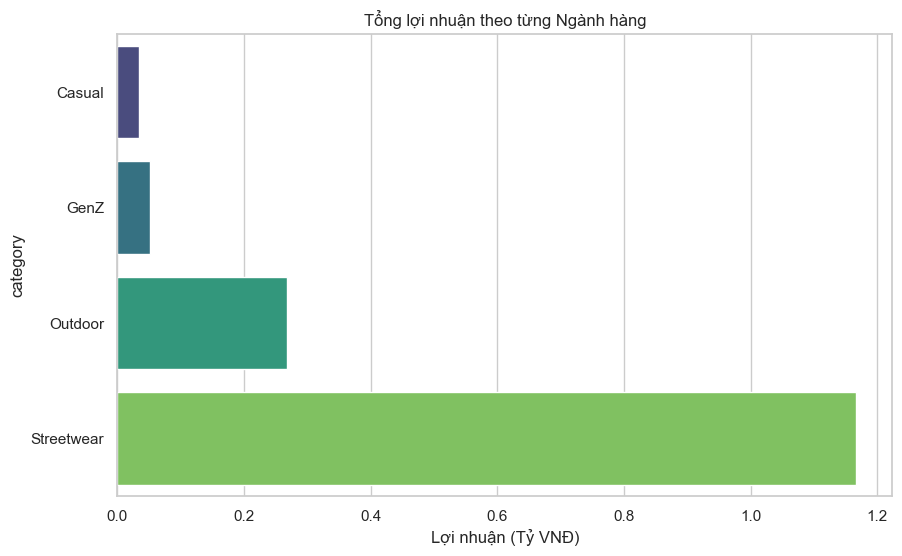

In [9]:
# Xem lợi nhuận của phần Cat nào cao nhất
cat_data = df_master.groupby('category')[['Revenue_line', 'Profit_line']].sum().reset_index()
cat_data = cat_data.sort_values('Profit_line', ascending=False)
cat_data['Profit_Billion'] = cat_data['Profit_line'] / 1e9

plt.figure(figsize=(10, 6))
sns.barplot(data=cat_data, x='Profit_Billion', y='category', hue='category', palette='viridis', legend=False)
plt.title('Tổng lợi nhuận theo từng Ngành hàng')
plt.xlabel('Lợi nhuận (Tỷ VNĐ)')
plt.show()

#### Insight:
The bar chart highlights that the **Streetwear** category is the primary profit driver, contributing approximately 1.17 billion VND. Directing targeted marketing budgets and optimizing inventory availability for this high-performing segment could further maximize cash flow.

### 3.2. Product Portfolio Analysis: Revenue vs. Margin

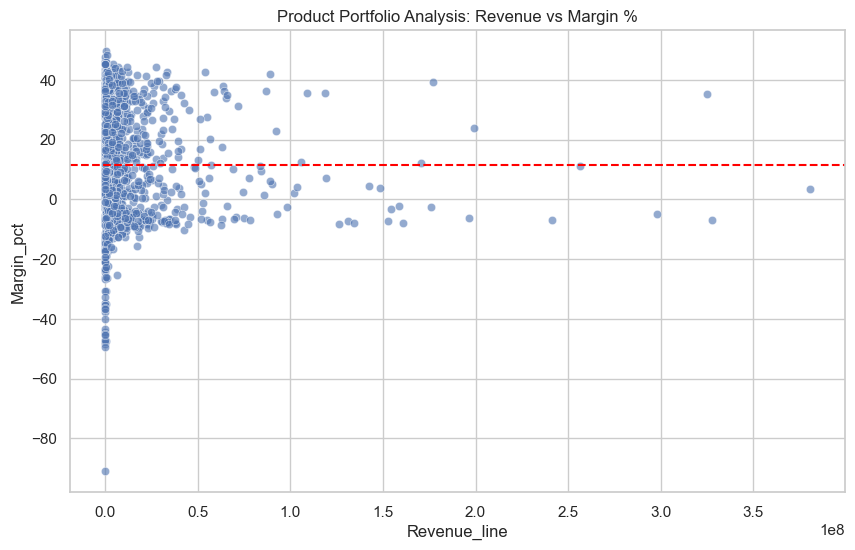

In [10]:
prod_analysis = df_master.groupby('product_name').agg({
    'Revenue_line': 'sum',
    'Profit_line': 'sum'
}).reset_index()
prod_analysis['Margin_pct'] = (prod_analysis['Profit_line'] / prod_analysis['Revenue_line']) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(data=prod_analysis, x='Revenue_line', y='Margin_pct', alpha=0.6)
plt.axhline(prod_analysis['Margin_pct'].mean(), color='red', linestyle='--', label='Average Margin')
plt.title('Product Portfolio Analysis: Revenue vs Margin %')
plt.show()

#### Insight:
This scatter plot maps the product portfolio based on total revenue and profit margin percentage. While most products cluster in the lower revenue spectrum, a few exceptional items drive substantial revenue with margins exceeding the **~16%** average. Notably, an extreme outlier exists in the bottom-left quadrant with a massive negative margin (approaching **-80%**), which requires immediate investigation to determine if it stems from pricing errors or highly aggressive loss-leader discounting strategies.

In [11]:
# Kiểm tra ouliers
outlier = prod_analysis.sort_values('Margin_pct').head(1)
display(outlier)

,product_name,Revenue_line,Profit_line,Margin_pct
1325,VietMode UR-02,15606.06,-14192.058,-90.939404


### 3.3. Daily Profit Trends

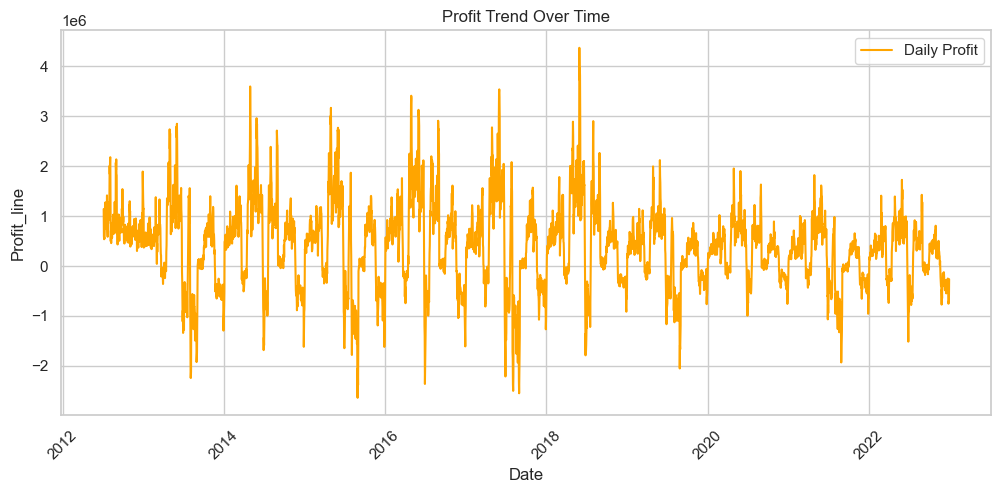

In [12]:
daily_trend = df_master.groupby('Date')[['Revenue_line', 'Profit_line']].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_trend, x='Date', y='Profit_line', color='orange', label='Daily Profit')
plt.title('Profit Trend Over Time')
plt.xticks(rotation=45)
plt.show()

#### Insight: 
The line chart illustrates the **daily profit fluctuations** over a decade. It is palpably evident that the business experiences **extreme volatility**, characterized by frequent peaks and significant "dips" where profit plummets into negative territory.

* **Seasonality:** The recurring spikes suggest a strong seasonal pattern, possibly linked to annual shopping festivals or holiday seasons.
* **Anomalies:** Several "deep dips" (negative profit) are observed periodically. These could be attributed to **aggressive loss-leader strategies** or major clearance sales aimed at inventory turnover rather than immediate margin.
* **Overall Trend:** Despite the volatility, the business maintains a relatively stable baseline, though a slight saturation is visible in the latter years (2020-2022).